In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader

#download data
training_data = datasets.MNIST(
    root="data", #folder to store
    train=True, #choose training set
    download=True, #not already downloaded
    #converts to tensor and then to float values
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

#prepare data
training_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

100.0%
100.0%
100.0%
100.0%


In [4]:
#define network

import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        #finding features
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), #32, 28, 28
            nn.ReLU(),
            nn.MaxPool2d(2),            #32, 14, 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1), #64, 14. 14
            nn.ReLU(),
            nn.MaxPool2d(2) # 64, 7, 7

        )

        #classifying
        self.classifier = nn.Sequential(
            nn.Flatten(), #64*7*7=3136
            nn.Linear(3136, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 10)
        )

        
    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x 

In [5]:
import numpy as np

model = CNN()
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) #lr=0.005

loss_history = []
test_loss_history = []
accuracy_history = []
test_accuracy_history = []

#training
for epoch in range(10):
    model.train() 
    epoch_losses = []
    correct = 0
    total = 0
    for x, y in training_dataloader:
        #keep first size (batch) (64) and infer the other automatically
        #x = x.view(x.size(0), -1) handled by Flatten
        y_pred = model(x)
        loss = loss_fn(y_pred,y)
        epoch_losses.append(loss.item())
        predicted = y_pred.argmax(dim=1)
        correct += (predicted == y).sum().item() #item transforms tensor to int
        total += y.size(0) #=64 (batch size)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    accuracy = correct/total
    accuracy_history.append(accuracy)
    print(accuracy_history)    

    model.eval() #switch to test
    epoch_test_losses = []
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            #x = x.view(x.size(0), -1) handled by flatten
            y_pred = model(x)
            loss = loss_fn(y_pred,y)
            epoch_test_losses.append(loss.item())
            predicted = y_pred.argmax(dim=1)
            correct_test += (predicted == y).sum().item() #item transforms tensor to int
            total_test += y.size(0) #=64 (batch size)
    avg_test_loss = np.mean(epoch_test_losses)
    test_loss_history.append(avg_test_loss)
    test_accuracy = correct_test/total_test
    test_accuracy_history.append(test_accuracy)
    print(test_accuracy_history)    




[0.9187833333333333]
[0.9798]
[0.9187833333333333, 0.9725333333333334]
[0.9798, 0.9884]
[0.9187833333333333, 0.9725333333333334, 0.9789833333333333]
[0.9798, 0.9884, 0.9892]
[0.9187833333333333, 0.9725333333333334, 0.9789833333333333, 0.9829666666666667]
[0.9798, 0.9884, 0.9892, 0.9892]
[0.9187833333333333, 0.9725333333333334, 0.9789833333333333, 0.9829666666666667, 0.98465]
[0.9798, 0.9884, 0.9892, 0.9892, 0.9903]
[0.9187833333333333, 0.9725333333333334, 0.9789833333333333, 0.9829666666666667, 0.98465, 0.9858666666666667]
[0.9798, 0.9884, 0.9892, 0.9892, 0.9903, 0.9924]
[0.9187833333333333, 0.9725333333333334, 0.9789833333333333, 0.9829666666666667, 0.98465, 0.9858666666666667, 0.9875666666666667]
[0.9798, 0.9884, 0.9892, 0.9892, 0.9903, 0.9924, 0.9924]
[0.9187833333333333, 0.9725333333333334, 0.9789833333333333, 0.9829666666666667, 0.98465, 0.9858666666666667, 0.9875666666666667, 0.98835]
[0.9798, 0.9884, 0.9892, 0.9892, 0.9903, 0.9924, 0.9924, 0.9932]
[0.9187833333333333, 0.97253333

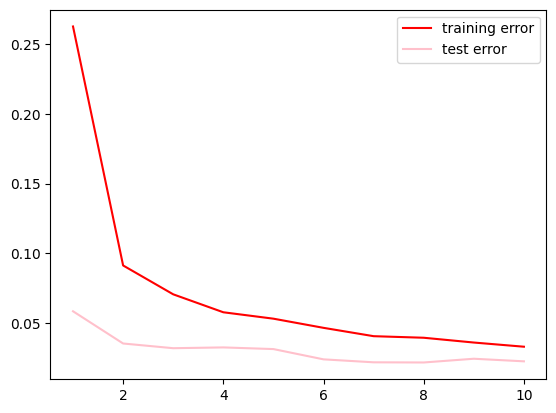

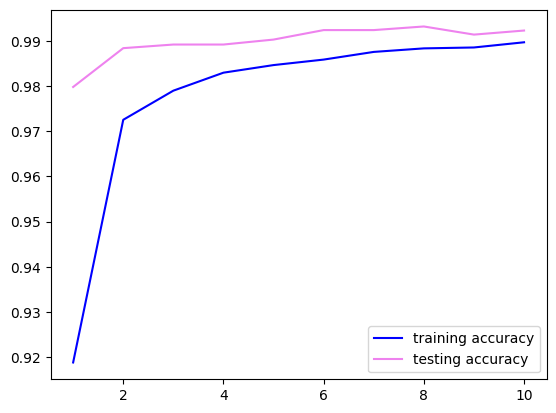

In [6]:
import matplotlib.pyplot as plt

x_axis = range(1, 11)
plt.plot(x_axis, loss_history, color="red", label="training error")
plt.plot(x_axis, test_loss_history, color="pink", label="test error")

plt.legend()
plt.show()

plt.plot(x_axis, accuracy_history, color="blue", label="training accuracy")
plt.plot(x_axis, test_accuracy_history, color="violet", label="testing accuracy")
plt.legend()
plt.show()

In [9]:
misclassified = {i:[] for i in range(10)}

model.eval()
with torch.no_grad():
    for x,y in test_dataloader: #batches
        #x_flat = x.view(x.size(0), -1) 
        preds = model(x).argmax(dim=1)
        wrong = preds != y

        for img, true_label, pred_label in zip(x[wrong], y[wrong], preds[wrong]):
            cls = true_label.item()
            if len(misclassified[cls])<10:
                misclassified[cls].append((img, true_label.item(), pred_label.item()))


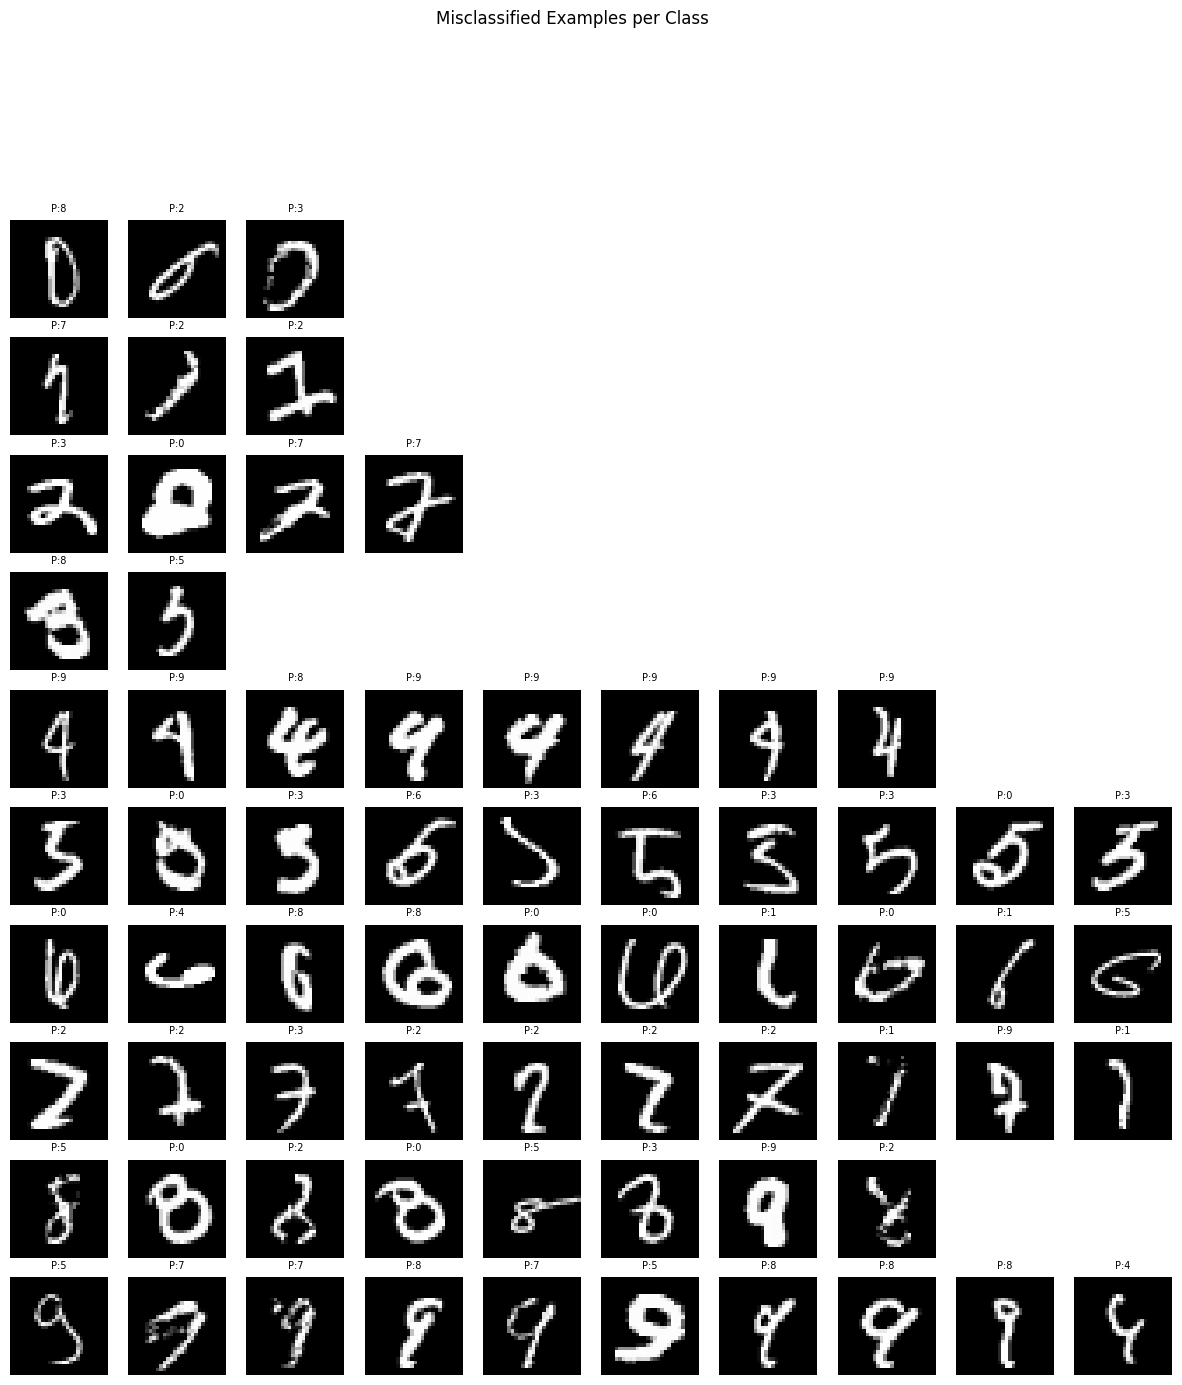

In [10]:
n_classes = 10
max_show = 10

fig, axes = plt.subplots(n_classes, max_show, figsize=(max_show*1.5, n_classes*1.5))

for cls in range(n_classes):
    examples = misclassified[cls]
    for col in range(max_show):
        ax = axes[cls][col]
        ax.axis("off")
        if col < len(examples):
            img, true_label, pred_label = examples[col]
            ax.imshow(img.squeeze(), cmap="gray")
            ax.set_title(f"P:{pred_label}", fontsize=7)

for cls in range(n_classes):
    axes[cls][0].set_ylabel(f"Class {cls}", fontsize=9, rotation=0, labelpad=35)

plt.suptitle("Misclassified Examples per Class", y=1.02)
plt.show()